## Building a Convolutional Neural Network using Pytorch from MNIST

In [ ]:
import math 
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd
import torch
from torch import rand
from torch import nn
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torch.nn.functional import one_hot

%matplotlib inline
np.random.seed(1)

In [31]:
train_data = MNIST(root="./data", train=True, download=True)
test_data = MNIST(root="./data", train=False, download=True)

print("Training set size:", len(train_data))
print("Test set size:", len(test_data))

# check the type/ format of the images in the dataset 
# pull out the first test image
print("Type of the images:", type(train_data[0]))
# hence (image, target) is stored in a tuple
print(type(train_data[0][0]), type(train_data[0][1]))
print(f"{train_data[0][0]}, {train_data[0][1]}")

Training set size: 60000
Test set size: 10000
Type of the images: <class 'tuple'>
<class 'PIL.Image.Image'> <class 'int'>
<PIL.Image.Image image mode=L size=28x28 at 0x1663893D0>, 5


Now we know that each test and train data sample is stored as (image, label) pair where:
+ 1st element: each image object is a 28x28 grayscale pixel data
+ 2nd element: integer 0 - 9 representing the digit class

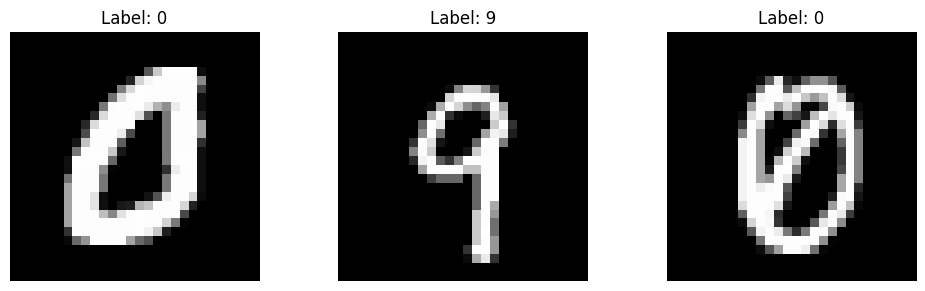

In [32]:
# visualising some of the images

fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(10, 3))

for ax, i in zip(ax, np.random.randint(0, 60000, 3)):
    image, label = train_data[i]
    ax.imshow(image, cmap="grey")
    ax.set_title(f"Label: {label}")
    ax.axis(("off"))

plt.tight_layout()
plt.show()


In [33]:
# Now we covert our PIL images into tensors
transform = transforms.Compose([
    transforms.ToTensor() # .Compose currently only holds one operation
    ])

train_data = MNIST(root="./data", train=True, download=False, transform=transform)
test_data = MNIST(root="./data", train=False, download=False, transform=transform)

#check that first element is now a tensor object
print(train_data[0][0])
# then check the shape of the image (now tensor object)
print(train_data[0][0].shape)

print(train_data[0][1])

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [34]:
print(train_data[0][0].device)
print(train_data[0][0].dtype)

cpu
torch.float32


In [39]:
X = torch.rand(5, 28, 28)
print(X)

tensor([[[0.4034, 0.5904, 0.1359,  ..., 0.2613, 0.2494, 0.5926],
         [0.8632, 0.4424, 0.9878,  ..., 0.9036, 0.9541, 0.1408],
         [0.6431, 0.3356, 0.1406,  ..., 0.9279, 0.3349, 0.9675],
         ...,
         [0.9239, 0.2783, 0.1735,  ..., 0.7935, 0.7957, 0.6897],
         [0.7127, 0.6922, 0.5917,  ..., 0.9580, 0.6671, 0.7939],
         [0.2343, 0.4416, 0.4583,  ..., 0.8708, 0.7192, 0.9252]],

        [[0.7524, 0.1689, 0.3076,  ..., 0.0499, 0.2505, 0.0759],
         [0.2396, 0.9191, 0.2482,  ..., 0.7984, 0.6501, 0.8234],
         [0.5394, 0.4539, 0.8358,  ..., 0.7678, 0.3221, 0.5484],
         ...,
         [0.2333, 0.7983, 0.0094,  ..., 0.1445, 0.8904, 0.3973],
         [0.1974, 0.5359, 0.9447,  ..., 0.9764, 0.5436, 0.6281],
         [0.1647, 0.7764, 0.3425,  ..., 0.9754, 0.6195, 0.9843]],

        [[0.5750, 0.7065, 0.2074,  ..., 0.5739, 0.9792, 0.2671],
         [0.0252, 0.4150, 0.6293,  ..., 0.5598, 0.5355, 0.5768],
         [0.3089, 0.7617, 0.0509,  ..., 0.7236, 0.3021, 0.